# HW2: Célzott és nem célzott poisoning támadás IDS ellen

## Tartalom
1. **Előkészítés** – Adat betöltés, előfeldolgozás, clean + surrogate modellek
2. **1. feladat** – Untargeted poisoning (random + loss-based)
3. **2. feladat** – Targeted poisoning (Witches' Brew)


## 0. Előkészítés

### 0.1 Importok és beállítások

In [1]:
!pip install numpy torch scikit-learn matplotlib pandas
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import json
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Device: cpu


### 0.2 Adat betöltés és előfeldolgozás

In [2]:
# Feature nevek betöltése
with open('../HW1/nslkdd_features.json', 'r') as f:
    features_info = json.load(f)
col_names = [f['name'] for f in features_info]

# Adat betöltése
train_df = pd.read_csv('../HW1/NSL-KDD/KDDTrain+.txt', header=None, names=col_names)
test_df  = pd.read_csv('../HW1/NSL-KDD/KDDTest+.txt',  header=None, names=col_names)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

# Bináris címkék: normal=0, attack=1
train_df['binary_label'] = (train_df['label'] != 'normal').astype(int)
test_df['binary_label']  = (test_df['label']  != 'normal').astype(int)

print("Train label eloszlás:", train_df['binary_label'].value_counts().to_dict())
print("Test label eloszlás:",  test_df['binary_label'].value_counts().to_dict())


Train: (125973, 43), Test: (22544, 43)
Train label eloszlás: {0: 67343, 1: 58630}
Test label eloszlás: {1: 12833, 0: 9711}


In [3]:
# One-hot encoding: protocol_type, service, flag
categorical_cols = ['protocol_type', 'service', 'flag']

# Train + test kombinálása konzisztens kódoláshoz
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols)

train_enc = combined_encoded.iloc[:len(train_df)].copy()
test_enc = combined_encoded.iloc[len(train_df):].copy().reset_index(drop=True)

# Feature és label szétválasztás
drop_cols = ['label', 'difficulty', 'binary_label']
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

X_train_full = train_enc[feature_cols].values.astype(np.float32)
y_train_full = train_enc['binary_label'].values.astype(np.float32)
X_test_all = test_enc[feature_cols].values.astype(np.float32)
y_test_all = test_enc['binary_label'].values.astype(np.float32)

input_dim = X_train_full.shape[1]
print(f"Feature-ök száma one-hot után: {input_dim}")


Feature-ök száma one-hot után: 122


In [4]:
# StandardScaler: train-en fit, mindkettőn transform
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full).astype(np.float32)
X_test_all = scaler.transform(X_test_all).astype(np.float32)

# Train/Validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

# Feature bounds (poison clipping-hez)
feat_min = X_train.min(axis=0)
feat_max = X_train.max(axis=0)

print(f"Train: {X_train.shape} (normal={int((y_train==0).sum())}, attack={int((y_train==1).sum())})")
print(f"Val:   {X_val.shape} (normal={int((y_val==0).sum())}, attack={int((y_val==1).sum())})")
print(f"Test:  {X_test_all.shape} (normal={int((y_test_all==0).sum())}, attack={int((y_test_all==1).sum())})")


Train: (100778, 122) (normal=53874, attack=46904)
Val:   (25195, 122) (normal=13469, attack=11726)
Test:  (22544, 122) (normal=9711, attack=12833)


### 0.3 Modell architektúra és segédfüggvények

In [5]:
class IntrusionDetector(nn.Module):
    """HW2 IDS modell: nincs Sigmoid a kimenetben, BCEWithLogitsLoss-t használunk."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        return self.net(x)


def train_ids(X_tr, y_tr, epochs=10, batch_size=128, lr=0.001, seed=None):
    """IDS modell tanítása. Visszaadja a betanított modellt."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    X_t = torch.FloatTensor(X_tr).to(device)
    y_t = torch.FloatTensor(y_tr).unsqueeze(1).to(device)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)
    
    model = IntrusionDetector(X_tr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
    
    return model


def predict(model, X):
    """Predikciók (0/1) numpy tömbként."""
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.FloatTensor(X).to(device)))
        return (probs > 0.5).float().cpu().numpy().flatten()


def get_accuracy(model, X, y):
    """Accuracy számítás."""
    return accuracy_score(y, predict(model, X))


### 0.4 Clean modell és 5 surrogate modell tanítása

In [6]:
# Clean modell tanítása a train halmazon
print("Clean modell tanítása...")
clean_model = train_ids(X_train, y_train, seed=SEED)
clean_train_acc = get_accuracy(clean_model, X_train, y_train)
clean_val_acc = get_accuracy(clean_model, X_val, y_val)
print(f"Clean modell - Train acc: {clean_train_acc:.4f}, Val acc: {clean_val_acc:.4f}")

# 5 surrogate modell tanítása a TESZT adaton
print("\n5 surrogate modell tanítása a tesztadaton...")
surrogates = []
for i in range(5):
    s = train_ids(X_test_all, y_test_all, seed=i * 1000 + 42)
    s_acc = get_accuracy(s, X_test_all, y_test_all)
    print(f"  Surrogate {i+1}: test acc = {s_acc:.4f}")
    surrogates.append(s)


Clean modell tanítása...
Clean modell - Train acc: 0.9961, Val acc: 0.9948

5 surrogate modell tanítása a tesztadaton...
  Surrogate 1: test acc = 0.9766
  Surrogate 2: test acc = 0.9755
  Surrogate 3: test acc = 0.9764
  Surrogate 4: test acc = 0.9755
  Surrogate 5: test acc = 0.9756


---
## 1. feladat: Untargeted Poisoning

A támadó célja a validációs pontosság lerontása azáltal, hogy átcímkézett mintákat ad a tanítóadathoz.

### Q1: Véletlenszerű kiválasztás (Random label flipping)

In [7]:
print("Q1: Random label flipping poisoning")
print("=" * 60)

p_values = [30, 50, 70]
q1_results = {p: [] for p in p_values}

for p in p_values:
    for trial in range(5):
        seed_t = trial * 111 + p
        np.random.seed(seed_t)
        
        # p% véletlenszerűen kiválasztott minta, invertált címkével hozzáadva
        n_poison = int(len(y_train) * p / 100)
        idx = np.random.choice(len(y_train), size=n_poison, replace=False)
        
        X_poisoned = np.concatenate([X_train, X_train[idx]])
        y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])
        
        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q1_results[p].append(val_a)
    
    print(f"  p={p}%: mean={np.mean(q1_results[p]):.4f} ± {np.std(q1_results[p]):.4f}")
    print(f"         values={[f'{v:.4f}' for v in q1_results[p]]}")


Q1: Random label flipping poisoning
  p=30%: mean=0.9905 ± 0.0015
         values=['0.9932', '0.9902', '0.9903', '0.9893', '0.9892']
  p=50%: mean=0.9891 ± 0.0009
         values=['0.9902', '0.9896', '0.9895', '0.9888', '0.9874']
  p=70%: mean=0.9840 ± 0.0021
         values=['0.9805', '0.9863', '0.9828', '0.9854', '0.9849']


### Q2: Loss-alapú kiválasztás

In [8]:
print("Q2: Loss-based label flipping poisoning")
print("=" * 60)

# Minden train mintára: átlagos loss invertált címkével az 5 surrogate-en
criterion_none = nn.BCEWithLogitsLoss(reduction='none')
X_t_tr = torch.FloatTensor(X_train).to(device)
y_inv = torch.FloatTensor(1.0 - y_train).unsqueeze(1).to(device)

all_losses = []
for sm in surrogates:
    sm.eval()
    with torch.no_grad():
        out = sm(X_t_tr)
        l = criterion_none(out, y_inv).cpu().numpy().flatten()
        all_losses.append(l)

avg_inv_loss = np.mean(all_losses, axis=0)
print(f"Invertált loss statisztikák: mean={avg_inv_loss.mean():.4f}, "
      f"min={avg_inv_loss.min():.4f}, max={avg_inv_loss.max():.4f}")


Q2: Loss-based label flipping poisoning
Invertált loss statisztikák: mean=11.9018, min=0.0000, max=622.1893


In [9]:
q2_results = {p: [] for p in p_values}

for p in p_values:
    # Legnagyobb átlagos invertált loss-ú minták felső p%-a
    n_poison = int(len(y_train) * p / 100)
    idx = np.argsort(avg_inv_loss)[-n_poison:]
    
    X_poisoned = np.concatenate([X_train, X_train[idx]])
    y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])
    
    for trial in range(5):
        seed_t = trial * 222 + p
        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q2_results[p].append(val_a)
    
    print(f"  p={p}%: mean={np.mean(q2_results[p]):.4f} ± {np.std(q2_results[p]):.4f}")
    print(f"         values={[f'{v:.4f}' for v in q2_results[p]]}")


  p=30%: mean=0.9829 ± 0.0033
         values=['0.9771', '0.9829', '0.9833', '0.9875', '0.9836']
  p=50%: mean=0.8403 ± 0.0990
         values=['0.8475', '0.9844', '0.8385', '0.8578', '0.6732']
  p=70%: mean=0.6992 ± 0.0483
         values=['0.7100', '0.7528', '0.6806', '0.7365', '0.6159']


### Box plot: Q1 vs Q2

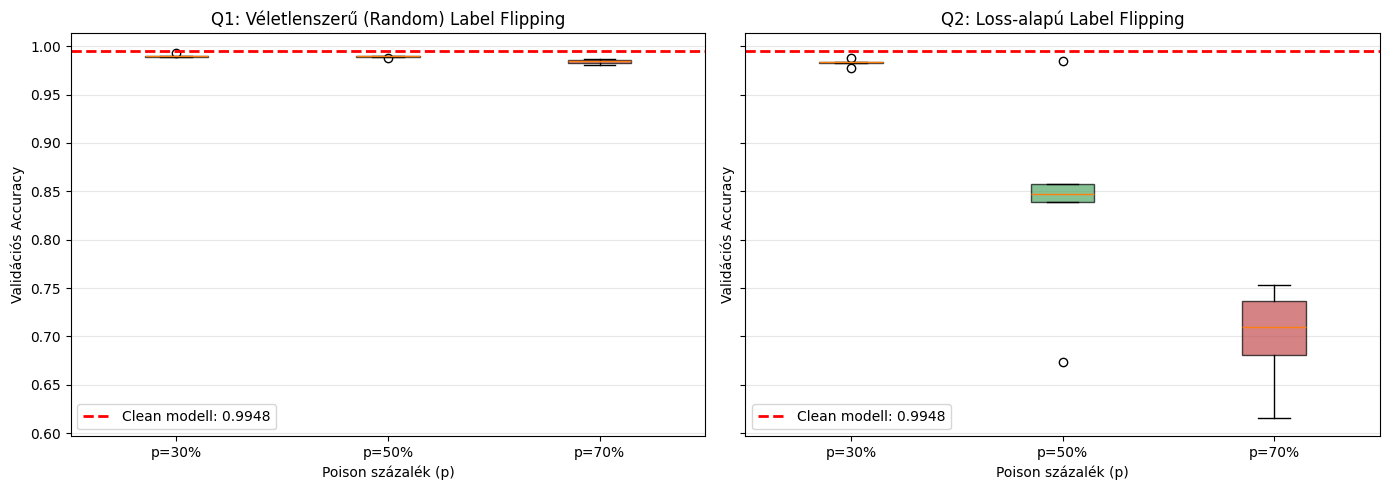

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, data, title in [
    (axes[0], q1_results, 'Q1: Véletlenszerű (Random) Label Flipping'),
    (axes[1], q2_results, 'Q2: Loss-alapú Label Flipping')
]:
    bp = ax.boxplot([data[p] for p in p_values],
                    labels=[f'p={p}%' for p in p_values], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(clean_val_acc, color='red', ls='--', lw=2,
               label=f'Clean modell: {clean_val_acc:.4f}')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Validációs Accuracy')
    ax.set_xlabel('Poison százalék (p)')
    ax.legend(loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_task1.png', dpi=150, bbox_inches='tight')
plt.show()


### Q3: Összehasonlítás

A **loss-based módszer hatékonyabb** a véletlennél, mert célzottan azokat a mintákat 
választja ki átcímkézésre, amelyek invertált címkéjére a legnagyobb a loss az 5 
surrogate modell átlagában. Ezek a minták a **döntési határ közelében** helyezkednek 
el, ahol az invertálásuk a legnagyobb zavart okozza a modell tanulásában.

A random módszer ezzel szemben egyenletesen választ, és sok "egyértelmű" mintát is 
átcímkéz (pl. nyilvánvaló normál forgalmat vagy egyértelmű támadást), amelyeknek az 
invertálása kevésbé rontja a modell teljesítményét, mert a modell könnyen felismeri 
a "hamis" címkét és negligálja.


### Q4: Gyakorlati elemzés

**Megvalósíthatóság:** A támadás feltételezi, hogy a támadó:
1. Hozzáfér a teljes tanítóadathoz
2. Képes mintákat hozzáadni a tanítóadathoz
3. Ismeri a modell architektúráját (loss-based esetben surrogate modellekhez)

A gyakorlatban ez lehetséges pl. crowdsourced adatgyűjtésnél, nyílt threat 
intelligence feed-eknél, vagy ha a támadó közvetlenül manipulálhatja a hálózati 
forgalmat amelyből az IDS tanul (pl. federated learning szcenárióban).

**Védekezési javaslatok:**
- **Data sanitization:** Anomális minták szűrése tanítás előtt (outlier detection, 
  isolation forest)
- **Confident Learning / cleanlab:** Automatikus zajos címke detekció; 
  cross-validation alapján azonosítja a potenciálisan hibás címkéjű mintákat
- **Robust training:** Trimmed mean loss, vagy csak a loss eloszlás közepét 
  használó minták tanítása
- **Differential Privacy (DP-SGD):** Csökkenti az egyes minták hatását a 
  modellre gradient clipping és noise hozzáadásával
- **Ensemble filtering:** Több modell konszenzusán alapuló szűrés – ha egy 
  minta több modell szerint is "gyanús", kizárásra kerül


---
## 2. feladat: Targeted Poisoning (Witches' Brew)

A cél: 10 target mintát félreklasszifikáltatni szennyezett adaton betanított modellel.

### 2.1 Target minták kiválasztása

In [11]:
print("Target minták kiválasztása a tesztadatból")
print("=" * 60)

clean_model.eval()
clean_preds = predict(clean_model, X_test_all)

# Feltételek: attack (y=1), clean modell helyesen klasszifikálja
attack_correct_mask = (y_test_all == 1) & (clean_preds == 1)
candidate_idx = np.where(attack_correct_mask)[0]
print(f"Helyesen klasszifikált attack minták a tesztben: {len(candidate_idx)}")

# Loss y_adv=0 (normal) címkére → minimálisat keressük (bizonytalan minták)
with torch.no_grad():
    X_cand_t = torch.FloatTensor(X_test_all[candidate_idx]).to(device)
    y_adv_cand = torch.zeros(len(candidate_idx), 1).to(device)
    out_cand = clean_model(X_cand_t)
    loss_on_normal = nn.BCEWithLogitsLoss(reduction='none')(out_cand, y_adv_cand)
    loss_on_normal = loss_on_normal.cpu().numpy().flatten()

# Top 10 legkisebb loss → leginkább bizonytalan
top10 = np.argsort(loss_on_normal)[:10]
target_indices = candidate_idx[top10]

print(f"\nKiválasztott 10 target index: {target_indices}")
print(f"Loss értékek y_adv=0 címkére: {np.round(loss_on_normal[top10], 4)}")
print(f"Eredeti címkék (mind 1 kell legyen): {y_test_all[target_indices]}")

X_targets = X_test_all[target_indices]
y_targets = y_test_all[target_indices]
y_adv = 0.0  # Célcímke: normal


Target minták kiválasztása a tesztadatból
Helyesen klasszifikált attack minták a tesztben: 8987

Kiválasztott 10 target index: [10863   994 21173  8660 19648 13631 11777  5016 14090  2696]
Loss értékek y_adv=0 címkére: [0.6962 0.6975 0.6987 0.6993 0.7007 0.7013 0.7037 0.7076 0.7081 0.7148]
Eredeti címkék (mind 1 kell legyen): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.2 Segédfüggvények a gradiens számításhoz

In [12]:
def get_param_grad(model, x, y_label, create_graph=False):
    """
    Gradiens szamitasa a BCEWithLogitsLoss-bol a modell paramétereire nezve.
    Ha create_graph=True, nem detacholja a bemenetet -> gradient atfolyik delta-n at.
    """
    model.eval()
    for param in model.parameters():
        param.requires_grad_(True)

    # create_graph=True eseten NEM detacholjuk: kell a gradient delta-hoz
    x_in = x.unsqueeze(0) if x.dim() == 1 else x
    if not create_graph:
        x_in = x_in.detach()
    x_in = x_in.to(next(model.parameters()).device)
    y_in = torch.tensor([[float(y_label)]], dtype=torch.float32, device=x_in.device)

    output = model(x_in)
    loss = nn.BCEWithLogitsLoss()(output, y_in)

    params = [p for p in model.parameters() if p.requires_grad]
    grads = torch.autograd.grad(loss, params, create_graph=create_graph)
    return torch.cat([g.flatten() for g in grads])


### 2.3 Base minták kiválasztása

In [13]:
def select_base_samples(target_x, y_adv_t, X_test, y_test, surrogates, p_count):
    """
    Base mintak kivalasztasa a teszthalmazbol:
    - Csak y_adv_t cimkeju (normal, y=0) mintak kozul
    - Amelyek gradiense a leghasonlobb a target gradiensehez (5 surrogate atlagan)
    Visszater: indexek csokkeno hasonlosagi sorrendben (legjobb elol).
    """
    cand_mask = (y_test == y_adv_t)
    cand_idx = np.where(cand_mask)[0]
    print(f"    Kandidatus base mintak szama (y={y_adv_t}): {len(cand_idx)}")

    # Target gradiensek eloszamitasa (minden surrogate-re, fixed)
    target_grads = []
    x_t = torch.FloatTensor(target_x).to(device)
    for model in surrogates:
        g = get_param_grad(model, x_t, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    # Koszinusz hasonlosag minden kandidatusra (5 modell atlaga)
    avg_sims = np.zeros(len(cand_idx))
    for bi in range(len(cand_idx)):
        ci = cand_idx[bi]
        x_c = torch.FloatTensor(X_test[ci]).to(device)
        sims = []
        for j, model in enumerate(surrogates):
            g_c = get_param_grad(model, x_c, y_test[ci], create_graph=False)
            for param in model.parameters():
                param.requires_grad_(False)
            sim = F.cosine_similarity(
                target_grads[j].unsqueeze(0), g_c.unsqueeze(0)
            ).item()
            sims.append(sim)
        avg_sims[bi] = np.mean(sims)
        if (bi + 1) % 1000 == 0:
            print(f"      Progress: {bi+1}/{len(cand_idx)}")

    # Top-p_count legnagyobb hasonlosagu, csokkeno sorrendben
    top_p_idx = np.argsort(avg_sims)[-p_count:][::-1]  # desc similarity
    selected = cand_idx[top_p_idx]
    sims_selected = avg_sims[np.argsort(avg_sims)[-p_count:][::-1]]
    print(f"    Kivalasztott {p_count} base minta, "
          f"cos sim: [{sims_selected[-1]:.4f}, {sims_selected[0]:.4f}]")
    return selected  # sorted best-first


### 2.4 Witches' Brew PGD támadás

In [14]:
def witches_brew_attack(target_x, y_adv_t, base_indices, X_test, y_test,
                         surrogates, feat_min_np, feat_max_np, max_iter=1000):
    """
    Witches' Brew poison crafting PGD optimalizacioval.

    Minimalizalando alignment loss (per-minta koztuk, nem osszegzett gradient):
    L = (1/5) * sum_j sum_i (1 - cos(grad_theta loss(theta_j, xt, y_adv),
                                       grad_theta loss(theta_j, xi+di, yi)))

    Masodrendu optimalizacio: delta_i-re derivalunk egy theta-gradiensen at.
    create_graph=True kell, es get_param_grad nem detacholja a bemenetet.
    """
    p = len(base_indices)
    fmin = torch.FloatTensor(feat_min_np).to(device)
    fmax = torch.FloatTensor(feat_max_np).to(device)

    # Target gradiensek eloszamitasa (fix, nem valtozik)
    x_target = torch.FloatTensor(target_x).to(device)
    target_grads = []
    for model in surrogates:
        g = get_param_grad(model, x_target, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    # Base tensorok es delta-k inicializalasa
    base_tensors = []
    base_labels = []
    deltas = []
    for i in range(p):
        bx = torch.FloatTensor(X_test[base_indices[i]]).to(device).detach()
        base_tensors.append(bx)
        base_labels.append(float(y_test[base_indices[i]]))
        delta = torch.zeros_like(bx, requires_grad=True)
        deltas.append(delta)

    optimizer = torch.optim.SGD(deltas, lr=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=75, eps=1e-06
    )

    best_loss = float('inf')
    best_deltas = [d.data.clone() for d in deltas]

    for it in range(max_iter):
        optimizer.zero_grad()

        total_loss = torch.zeros(1, device=device)[0]  # differentiable zero

        for j, model in enumerate(surrogates):
            model.eval()
            for param in model.parameters():
                param.requires_grad_(True)

            for i in range(p):
                # Poison minta: base + delta, [feat_min, feat_max] kozott
                poison_x = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)

                # Gradient a modell parameterekre nezve
                # create_graph=True: differencialhato a delta_i-re is
                g_poison = get_param_grad(
                    model, poison_x, base_labels[i], create_graph=True
                )

                cos_sim = F.cosine_similarity(
                    target_grads[j].unsqueeze(0),
                    g_poison.unsqueeze(0)
                )
                total_loss = total_loss + (1.0 - cos_sim.squeeze())

        total_loss = total_loss / 5.0
        total_loss.backward()  # gradiens delta-kra es (mellekesen) model parameterekre

        optimizer.step()
        scheduler.step(total_loss.item())

        # Modell parameterek gradiensenek nullazasa es kikapcsolasa
        for model in surrogates:
            model.zero_grad()
            for param in model.parameters():
                param.requires_grad_(False)

        # Delta clamp: base+delta a [feat_min, feat_max] tartomanyban maradjon
        with torch.no_grad():
            for i in range(p):
                clamped = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)
                deltas[i].data = clamped - base_tensors[i]

        loss_val = total_loss.item()
        if loss_val < best_loss:
            best_loss = loss_val
            best_deltas = [d.data.clone() for d in deltas]

        if it % 200 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"      Iter {it}/{max_iter}: loss={loss_val:.6f}, lr={lr_now:.6f}")

    print(f"      Best loss: {best_loss:.6f}")

    # Poison mintak osszeallitasa (best delta hasznalataval)
    poison_X = []
    poison_y = []
    for i in range(p):
        px = torch.clamp(base_tensors[i] + best_deltas[i], fmin, fmax)
        poison_X.append(px.cpu().numpy())
        poison_y.append(base_labels[i])
    return np.array(poison_X, dtype=np.float32), np.array(poison_y, dtype=np.float32)


### 2.5 Támadás végrehajtása (p ∈ {5, 15})

In [15]:
targeted_results = {}

# Eloszamitas: base mintak (max 15) minden target-re egyszer
# p=5 eseten az elso 5 legjobbat hasznaljuk (sorted desc)
print("Base mintak eloszamitasa minden target-re...")
all_base_idx = {}  # t_idx -> top-15 base indices (desc similarity)
for t_pos, t_idx in enumerate(target_indices):
    print("\n  Target " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ") base kivalasztas...")
    base_idx_15 = select_base_samples(
        X_test_all[t_idx], y_adv, X_test_all, y_test_all, surrogates, p_count=15
    )
    all_base_idx[t_idx] = base_idx_15  # top 15, legjobb elol

for p_base in [5, 15]:
    print()
    print("=" * 70)
    print("TARGETED POISONING: p = " + str(p_base) + " base minta target-enkent")
    print("=" * 70)

    successes = 0

    for t_pos, t_idx in enumerate(target_indices):
        print("\n  --- Target " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ") ---")

        # Top-p_base base mintak kivalasztasa (legjobb elol, ezert [:p_base])
        base_idx = all_base_idx[t_idx][:p_base]

        # WiB PGD optimalizacio
        print("    WiB PGD (1000 iter, p=" + str(p_base) + ")...")
        poison_X, poison_y = witches_brew_attack(
            X_test_all[t_idx], y_adv, base_idx,
            X_test_all, y_test_all, surrogates,
            feat_min, feat_max, max_iter=1000
        )

        # Retrain szennyezett adaton + kievertekeles
        X_poisoned = np.concatenate([X_train, poison_X])
        y_poisoned = np.concatenate([y_train, poison_y])

        retrained = train_ids(X_poisoned, y_poisoned, seed=int(t_idx) + 9999)
        pred = predict(retrained, X_test_all[t_idx:t_idx+1])

        is_success = (pred[0] == y_adv)
        if is_success:
            successes += 1

        result_str = "SIKERES" if is_success else "SIKERTELEN"
        print("    Predikcio: " + str(int(pred[0])) + ", Cel (y_adv): " + str(int(y_adv)) + " -> " + result_str)

    attack_rate = successes / 10
    targeted_results[p_base] = {'successes': successes, 'rate': attack_rate}
    print("\n  >> Tamadas sikeressege p=" + str(p_base) + ": " + str(successes) + "/10 = " + f"{attack_rate:.0%}")


Base mintak eloszamitasa minden target-re...

  Target 1/10 (test index=10863) base kivalasztas...
    Kandidatus base mintak szama (y=0.0): 9711
      Progress: 1000/9711
      Progress: 2000/9711
      Progress: 3000/9711
      Progress: 4000/9711
      Progress: 5000/9711
      Progress: 6000/9711
      Progress: 7000/9711
      Progress: 8000/9711
      Progress: 9000/9711
    Kivalasztott 15 base minta, cos sim: [0.4437, 0.8274]

  Target 2/10 (test index=994) base kivalasztas...
    Kandidatus base mintak szama (y=0.0): 9711
      Progress: 1000/9711
      Progress: 2000/9711
      Progress: 3000/9711
      Progress: 4000/9711
      Progress: 5000/9711
      Progress: 6000/9711
      Progress: 7000/9711
      Progress: 8000/9711
      Progress: 9000/9711
    Kivalasztott 15 base minta, cos sim: [0.4436, 0.8274]

  Target 3/10 (test index=21173) base kivalasztas...
    Kandidatus base mintak szama (y=0.0): 9711
      Progress: 1000/9711
      Progress: 2000/9711
      Progress: 30

### 2.6 Eredmények összefoglalása

ÖSSZEFOGLALÓ

Clean modell validációs accuracy: 0.9948

--- 1. feladat: Untargeted Poisoning ---
Módszer                        p=30%      p=50%      p=70%
-------------------------------------------------------
Q1: Random                    0.9905     0.9891     0.9840
Q2: Loss-based                0.9829     0.8403     0.6992

--- 2. feladat: Targeted Poisoning (WiB) ---
  p=5: 9/10 sikeresen félreklasszifikálva (90%)
  p=15: 10/10 sikeresen félreklasszifikálva (100%)


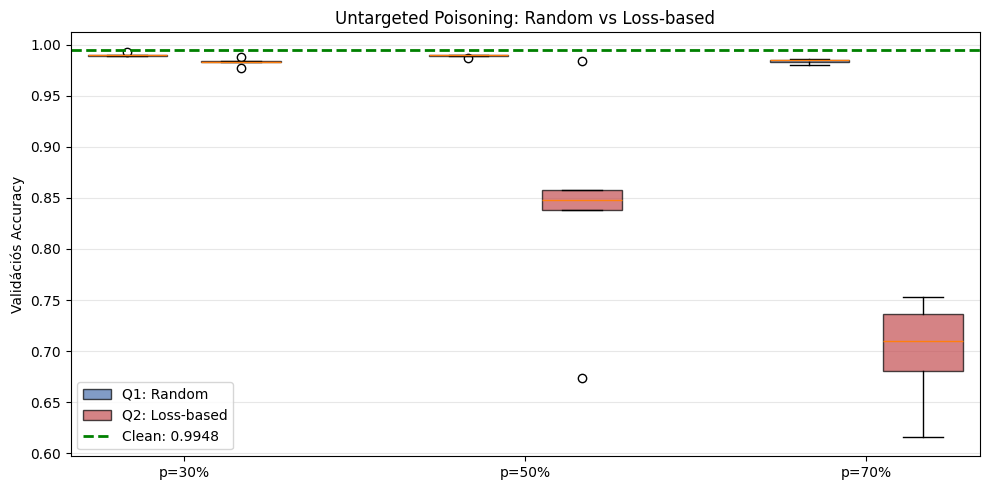

In [16]:
print("=" * 70)
print("ÖSSZEFOGLALÓ")
print("=" * 70)

print(f"\nClean modell validációs accuracy: {clean_val_acc:.4f}")

print(f"\n--- 1. feladat: Untargeted Poisoning ---")
print(f"{'Módszer':<25} {'p=30%':>10} {'p=50%':>10} {'p=70%':>10}")
print("-" * 55)
print(f"{'Q1: Random':<25} "
      f"{np.mean(q1_results[30]):>10.4f} "
      f"{np.mean(q1_results[50]):>10.4f} "
      f"{np.mean(q1_results[70]):>10.4f}")
print(f"{'Q2: Loss-based':<25} "
      f"{np.mean(q2_results[30]):>10.4f} "
      f"{np.mean(q2_results[50]):>10.4f} "
      f"{np.mean(q2_results[70]):>10.4f}")

print(f"\n--- 2. feladat: Targeted Poisoning (WiB) ---")
for p_b, res in targeted_results.items():
    print(f"  p={p_b}: {res['successes']}/10 sikeresen félreklasszifikálva ({res['rate']:.0%})")

# Combined box plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
positions_q1 = [1, 4, 7]
positions_q2 = [2, 5, 8]

bp1 = ax.boxplot([q1_results[p] for p in p_values], positions=positions_q1,
                  patch_artist=True, widths=0.7)
bp2 = ax.boxplot([q2_results[p] for p in p_values], positions=positions_q2,
                  patch_artist=True, widths=0.7)

for patch in bp1['boxes']:
    patch.set_facecolor('#4C72B0'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#C44E52'); patch.set_alpha(0.7)

ax.axhline(clean_val_acc, color='green', ls='--', lw=2, label=f'Clean: {clean_val_acc:.4f}')
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(['p=30%', 'p=50%', 'p=70%'])
ax.set_ylabel('Validációs Accuracy')
ax.set_title('Untargeted Poisoning: Random vs Loss-based')
ax.legend([bp1['boxes'][0], bp2['boxes'][0], ax.lines[-1]],
          ['Q1: Random', 'Q2: Loss-based', f'Clean: {clean_val_acc:.4f}'],
          loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('combined_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 2. feladat Q2: Gyakorlati elemzés és védekezés

**Megvalósíthatóság a gyakorlatban:**

A Witches' Brew támadás erős feltételezéseket igényel:
1. A támadó ismeri a modell architektúráját és hyperparamétereit
2. Hozzáfér a tesztadathoz (target és base minták kiválasztásához)
3. Képes mintákat hozzáadni a tanítóadathoz
4. Be tud tanítani surrogate modelleket a tesztadaton

A gyakorlatban ez ritka, de előfordulhat federated learning, adatmegosztásos 
vagy crowdsourced adatgyűjtési szcenáriókban.

**Védekezési javaslatok:**
- **Spectral signatures:** A poison minták jellemzően specifikus irányba 
  tolják el a belső reprezentációkat; PCA/SVD alapú szűréssel detektálhatók 
  (Tran et al., 2018).
- **Activation clustering:** A poison minták aktivációi a belső rétegeken 
  eltérnek a "valódi" mintákétól; klaszterezéssel azonosíthatók.
- **Differential Privacy (DP-SGD):** A gradient clipping és zajhozzáadás 
  csökkenti a kis számú poison minta hatását a modellparaméterekre.
- **Gradient-based filtering:** Szokatlanul nagy vagy specifikus irányú 
  gradiensű tanítóminták eltávolítása.
- **Ensemble training:** Több random inicializálással tanított modell 
  aggregálása (voting) csökkenti a targeted poison hatékonyságát, mert 
  a támadásnak egyszerre kellene minden modellt megtévesztenie.
